# Olist 고객 만족도 예측 및 세그먼트별 매출 성장 분석
## 마켓컬리 BA 직무용 | Kaggle Olist E-Commerce Dataset

**목표**: 컬리 비즈니스 고민(수익성, 배송 만족도, 카테고리 확장)을 데이터 기반으로 해결
- Step 1: 카테고리 ABCD 그룹핑
- Step 2: K-Means 고객 세그먼트 + 페르소나
- Step 3: 세그먼트별 만족도 예측 (ML)
- Step 4: 세그먼트별 매출 시계열 예측

In [10]:
# 필수 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 데이터 경로 (프로젝트 루트 기준)
DATA_DIR = 'data/'

---
## 데이터 로드 및 기본 병합

In [11]:
# 주문, 주문상품, 상품, 카테고리 번역, 리뷰, 고객, 결제 로드
orders = pd.read_csv(f'{DATA_DIR}orders.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
order_items = pd.read_csv(f'{DATA_DIR}order_items.csv', parse_dates=['shipping_limit_date'])
products = pd.read_csv(f'{DATA_DIR}products.csv')
category_translation = pd.read_csv(f'{DATA_DIR}category_translation.csv')
order_reviews = pd.read_csv(f'{DATA_DIR}order_reviews.csv', parse_dates=['review_creation_date'])
customers = pd.read_csv(f'{DATA_DIR}customers.csv')
order_payments = pd.read_csv(f'{DATA_DIR}order_payments.csv')

# delivered 주문만 사용 (분석 일관성)
orders = orders[orders['order_status'] == 'delivered'].copy()

# 상품-영문 카테고리 매핑
products = products.merge(category_translation, on='product_category_name', how='left')

# 주문-아이템-상품(영문카테고리) 병합
oi = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
oi = oi.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']], on='order_id', how='inner')

# 고객 unique_id 매핑
oi = oi.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# 결제: 주문별 총 결제액
order_total = order_payments.groupby('order_id').agg(payment_value=('payment_value', 'sum')).reset_index()
oi = oi.merge(order_total, on='order_id', how='left')

print('병합 후 주문-아이템 행 수:', len(oi))
oi.head()

병합 후 주문-아이템 행 수: 110197


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900,13.290,cool_stuff,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,72.190
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900,19.930,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,259.830
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000,17.870,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,216.870
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.990,12.790,perfumery,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,25.780
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.900,18.140,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,218.040


---
## Step 1: 카테고리 ABCD 그룹핑 (`category_group` 생성)

In [12]:
def map_category_to_group(english_name):
    """
    product_category_name_english -> A/B/C/D 그룹 매핑
    A: 신선/필수 식품, B: 뷰티/패션, C: 라이프스타일, D: 고가 가전
    """
    if pd.isna(english_name):
        return 'C'  # 결측은 라이프스타일로
    e = str(english_name).lower()
    # Group A: 신선/필수 식품
    if e in ('food', 'drinks', 'food_drink', 'la_cuisine') or 'food' in e or 'drink' in e:
        return 'A'
    if e == 'agro_industry_and_commerce':
        return 'A'
    # Group B: 뷰티/패션
    if e in ('health_beauty', 'perfumery'):
        return 'B'
    if 'fashion' in e or e.startswith('fashio_'):  # fashio_female_clothing 오타 반영
        return 'B'
    # Group D: 고가 가전
    if e in ('computers_accessories', 'computers', 'telephony', 'fixed_telephony', 'electronics',
             'small_appliances', 'home_appliances', 'home_appliances_2', 'audio', 'air_conditioning',
             'tablets_printing_image', 'consoles_games', 'cine_photo', 'small_appliances_home_oven_and_coffee'):
        return 'D'
    # Group C: 라이프스타일 (나머지)
    return 'C'

# 적용
oi['category_group'] = oi['product_category_name_english'].map(map_category_to_group)

print('category_group 분포:')
print(oi['category_group'].value_counts().sort_index())
print('\n샘플 확인:')
oi[['product_category_name_english', 'category_group']].drop_duplicates().sort_values('category_group').head(20)

category_group 분포:
category_group
A     1349
B    15380
C    74602
D    18866
Name: count, dtype: int64

샘플 확인:


,product_category_name_english,category_group
12453,la_cuisine,A
704,food_drink,A
734,drinks,A
30,agro_industry_and_commerce,A
28,food,A
26485,fashion_childrens_clothes,B
679,fashion_underwear_beach,B
694,fashion_male_clothing,B
1070,fashion_shoes,B
1385,fashio_female_clothing,B


In [13]:
# 시각화: 그룹별 주문 금액 비중
group_amount = oi.groupby('category_group').agg(amount=('price', 'sum')).assign(pct=lambda x: x['amount'] / x['amount'].sum() * 100)
fig = px.pie(values=group_amount['pct'], names=group_amount.index, title='카테고리 그룹별 매출 비중 (%)',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

---
## Step 2: 고객별 Feature 생성 및 K-Means 세그먼트

In [14]:
# 고객별 집계: 그룹 A/B/C/D 금액, 총 주문 수, 객단가, 배송비 비중
customer_order_totals = oi.groupby(['customer_unique_id', 'order_id']).agg(
    order_amount=('price', 'sum'),
    order_freight=('freight_value', 'sum'),
    order_payment=('payment_value', 'first')  # 주문당 결제액 1개
).reset_index()

# 주문당 그룹별 금액
order_group_amount = oi.pivot_table(
    index=['customer_unique_id', 'order_id'],
    columns='category_group',
    values='price',
    aggfunc='sum',
    fill_value=0
).reset_index()

for g in ['A', 'B', 'C', 'D']:
    if g not in order_group_amount.columns:
        order_group_amount[g] = 0

order_group_amount = order_group_amount.merge(
    customer_order_totals[['customer_unique_id', 'order_id', 'order_amount', 'order_freight', 'order_payment']],
    on=['customer_unique_id', 'order_id'], how='left'
)

# 고객별 Feature
customer_features = order_group_amount.groupby('customer_unique_id').agg(
    total_amount=('order_amount', 'sum'),
    total_freight=('order_freight', 'sum'),
    frequency=('order_id', 'nunique'),
    amount_a=('A', 'sum'),
    amount_b=('B', 'sum'),
    amount_c=('C', 'sum'),
    amount_d=('D', 'sum'),
).reset_index()

customer_features['pct_a'] = customer_features['amount_a'] / customer_features['total_amount'].replace(0, np.nan)
customer_features['pct_b'] = customer_features['amount_b'] / customer_features['total_amount'].replace(0, np.nan)
customer_features['pct_c'] = customer_features['amount_c'] / customer_features['total_amount'].replace(0, np.nan)
customer_features['pct_d'] = customer_features['amount_d'] / customer_features['total_amount'].replace(0, np.nan)
customer_features['pct_a'] = customer_features['pct_a'].fillna(0)
customer_features['pct_b'] = customer_features['pct_b'].fillna(0)
customer_features['pct_c'] = customer_features['pct_c'].fillna(0)
customer_features['pct_d'] = customer_features['pct_d'].fillna(0)

customer_features['aov'] = customer_features['total_amount'] / customer_features['frequency']
customer_features['freight_ratio'] = customer_features['total_freight'] / customer_features['total_amount'].replace(0, np.nan)
customer_features['freight_ratio'] = customer_features['freight_ratio'].fillna(0)

print('고객별 Feature 요약 (전처리 전):')
feature_cols = ['pct_a', 'pct_b', 'pct_c', 'pct_d', 'frequency', 'aov', 'freight_ratio']
customer_features[feature_cols].describe()

고객별 Feature 요약 (전처리 전):


,pct_a,pct_b,pct_c,pct_d,frequency,aov,freight_ratio
count,93358.000,93358.000,93358.000,93358.000,93358.000,93358.000,93358.000
mean,0.012,0.145,0.668,0.175,1.033,137.508,0.306
std,0.107,0.351,0.469,0.379,0.209,209.860,0.309
min,0.000,0.000,0.000,0.000,1.000,0.850,0.000
25%,0.000,0.000,0.000,0.000,1.000,46.000,0.132
50%,0.000,0.000,1.000,0.000,1.000,86.990,0.224
75%,0.000,0.000,1.000,0.000,1.000,149.900,0.378
max,1.000,1.000,1.000,1.000,15.000,13440.000,21.447


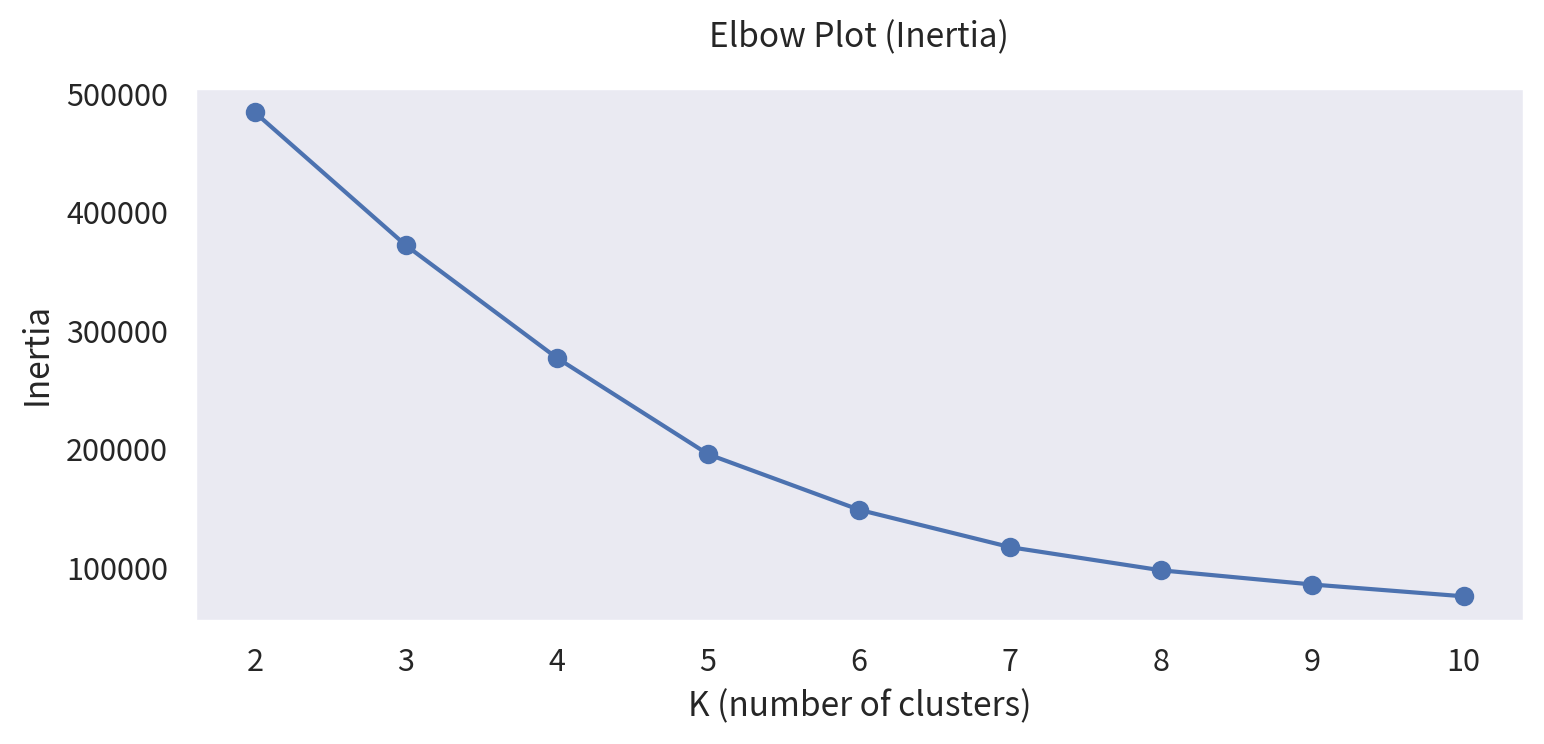

클러스터별 평균 Feature:


,pct_a,pct_b,pct_c,pct_d,frequency_log,aov_log,freight_ratio,frequency,aov
cluster,,,,,,,,,
0,0.000,0.000,0.003,0.997,0.703,4.184,0.405,1.026,137.064
1,0.991,0.002,0.004,0.003,0.707,4.162,0.356,1.034,123.645
2,0.000,0.001,0.998,0.001,0.707,4.546,0.282,1.035,139.335
3,0.000,0.995,0.004,0.001,0.707,4.449,0.277,1.034,130.731



클러스터 크기:
cluster
0    16330
1     1085
2    62411
3    13532
Name: count, dtype: int64

=== 클러스터 해석 ===
Cluster 0: low AOV / low frequency / D-dominant basket / high freight ratio
Cluster 1: low AOV / low frequency / A-dominant basket / high freight ratio
Cluster 2: high AOV / high frequency / C-dominant basket / low freight ratio
Cluster 3: high AOV / high frequency / B-dominant basket / low freight ratio


In [15]:
# ========== 1) 이상치 처리: freight_ratio >= 2 -> 2로 cap ==========
customer_features['freight_ratio'] = customer_features['freight_ratio'].clip(upper=2)

# ========== 2) 로그 변환: aov, frequency -> aov_log, frequency_log ==========
customer_features['aov_log'] = np.log1p(customer_features['aov'])
customer_features['frequency_log'] = np.log1p(customer_features['frequency'])

# ========== 3) 클러스터링 Feature 정의 ==========
cluster_features = ['pct_a', 'pct_b', 'pct_c', 'pct_d', 'frequency_log', 'aov_log', 'freight_ratio']

# ========== 4) 결측/무한값 처리 ==========
X = (customer_features[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0))

# ========== 5) StandardScaler 적용 ==========
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ========== 6) Elbow Method (k=2~10) ==========
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'bo-')
ax.set_xlabel('K (number of clusters)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Plot (Inertia)')
plt.tight_layout()
plt.show()

# ========== 7) KMeans 모델 생성 (k=4), cluster 라벨 부여 ==========
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
customer_features['cluster'] = kmeans.fit_predict(X_scaled)
# Step 3/4 호환용 segment 라벨 (Segment_1 ~ Segment_4)
customer_features['segment'] = 'Segment_' + (customer_features['cluster'] + 1).astype(str)

# ========== 8) 클러스터 요약 (평균) ==========
cluster_summary = customer_features.groupby('cluster')[cluster_features + ['frequency', 'aov']].mean().round(4)
print('클러스터별 평균 Feature:')
display(cluster_summary)

# ========== 9) 클러스터 크기 ==========
cluster_sizes = customer_features['cluster'].value_counts().sort_index()
print('\n클러스터 크기:')
print(cluster_sizes)

# ========== 10) 클러스터 해석 (사람이 이해할 수 있는 요약) ==========
med_aov = cluster_summary['aov_log'].median()
med_freq = cluster_summary['frequency_log'].median()
med_freight = cluster_summary['freight_ratio'].median()

def dominant_bucket(row):
    pct_cols = ['pct_a', 'pct_b', 'pct_c', 'pct_d']
    dom = row[pct_cols].idxmax()
    return dom.replace('pct_', '').upper()

print('\n=== 클러스터 해석 ===')
for c in cluster_summary.index:
    row = cluster_summary.loc[c]
    tags = []
    tags.append('high AOV' if row['aov_log'] >= med_aov else 'low AOV')
    tags.append('high frequency' if row['frequency_log'] >= med_freq else 'low frequency')
    tags.append(dominant_bucket(row) + '-dominant basket')
    tags.append('high freight ratio' if row['freight_ratio'] >= med_freight else 'low freight ratio')
    print(f"Cluster {c}: " + " / ".join(tags))

In [16]:
# 세그먼트(클러스터)별 평균 프로필 요약 (시각화·하위 단계용)
segment_profile = customer_features.groupby('segment')[feature_cols + ['total_amount', 'frequency']].mean().round(4)
segment_profile['고객수'] = customer_features.groupby('segment').size()
segment_profile = segment_profile.reset_index()
print('세그먼트별 평균 Feature (시각화용):')
display(segment_profile)

# 페르소나 라벨: 위에서 출력한 클러스터 해석을 segment별로 매핑
med_aov = cluster_summary['aov_log'].median()
med_freq = cluster_summary['frequency_log'].median()
med_freight = cluster_summary['freight_ratio'].median()
persona_map = {}
for c in cluster_summary.index:
    seg = f'Segment_{c+1}'
    row = cluster_summary.loc[c]
    tags = []
    tags.append('high AOV' if row['aov_log'] >= med_aov else 'low AOV')
    tags.append('high frequency' if row['frequency_log'] >= med_freq else 'low frequency')
    tags.append(dominant_bucket(row) + '-dominant')
    persona_map[seg] = ' / '.join(tags)
customer_features['persona'] = customer_features['segment'].map(persona_map)

세그먼트별 평균 Feature (시각화용):


,segment,pct_a,pct_b,pct_c,pct_d,frequency,aov,freight_ratio,total_amount,frequency,고객수
0,Segment_1,0.000,0.000,0.003,0.997,1.026,137.064,0.405,140.920,1.026,16330
1,Segment_2,0.991,0.002,0.004,0.003,1.034,123.645,0.356,126.508,1.034,1085
2,Segment_3,0.000,0.001,0.998,0.001,1.035,139.335,0.282,143.624,1.035,62411
3,Segment_4,0.000,0.995,0.004,0.001,1.034,130.731,0.277,134.446,1.034,13532


In [17]:
# 세그먼트별 프로필 시각화 (대시보드 스타일)
seg_agg = customer_features.groupby('segment').agg({
    'pct_a': 'mean', 'pct_b': 'mean', 'pct_c': 'mean', 'pct_d': 'mean',
    'frequency': 'mean', 'aov': 'mean', 'freight_ratio': 'mean', 'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'count'})
seg_agg = seg_agg.reset_index()

fig = make_subplots(rows=2, cols=2, subplot_titles=('그룹별 구매 비중', '주문 빈도', '평균 객단가', '배송비 비중'),
                    specs=[[{'type': 'bar'}, {'type': 'bar'}], [{'type': 'bar'}, {'type': 'bar'}]])
x = seg_agg['segment']
fig.add_trace(go.Bar(name='A', x=x, y=seg_agg['pct_a']), row=1, col=1)
fig.add_trace(go.Bar(name='B', x=x, y=seg_agg['pct_b']), row=1, col=1)
fig.add_trace(go.Bar(name='C', x=x, y=seg_agg['pct_c']), row=1, col=1)
fig.add_trace(go.Bar(name='D', x=x, y=seg_agg['pct_d']), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=seg_agg['frequency'], name='Frequency'), row=1, col=2)
fig.add_trace(go.Bar(x=x, y=seg_agg['aov'], name='AOV'), row=2, col=1)
fig.add_trace(go.Bar(x=x, y=seg_agg['freight_ratio'], name='Freight Ratio'), row=2, col=2)
fig.update_layout(height=500, title_text='세그먼트별 고객 프로필')
fig.show()

---
## Step 3: 세그먼트별 만족도 예측 (review_score 4–5 만족 / 1–3 불만족)

In [18]:
# 주문-리뷰-고객-세그먼트 병합 + 주문 수준 Feature
order_level = oi.groupby('order_id').agg(
    order_amount=('price', 'sum'),
    order_freight=('freight_value', 'sum'),
    customer_unique_id=('customer_unique_id', 'first'),
    order_purchase_timestamp=('order_purchase_timestamp', 'first'),
    order_delivered_customer_date=('order_delivered_customer_date', 'first'),
    order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),
).reset_index()

order_level['freight_ratio_order'] = order_level['order_freight'] / order_level['order_amount'].replace(0, np.nan)
order_level['freight_ratio_order'] = order_level['freight_ratio_order'].fillna(0)
order_level['delivery_delay_days'] = (
    order_level['order_delivered_customer_date'] - order_level['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 3600)
order_level['delivery_delay_days'] = order_level['delivery_delay_days'].fillna(0)  # 미배송 등

order_level = order_level.merge(
    customer_features[['customer_unique_id', 'segment', 'frequency', 'aov', 'freight_ratio']],
    on='customer_unique_id', how='left', suffixes=('', '_cust')
)

reviews = order_reviews[['order_id', 'review_score']].drop_duplicates(subset=['order_id'])
order_level = order_level.merge(reviews, on='order_id', how='inner')

# Target: 4–5 만족(1), 1–3 불만족(0)
order_level['satisfied'] = (order_level['review_score'] >= 4).astype(int)

# 모델용 Feature
model_cols = ['order_amount', 'freight_ratio_order', 'delivery_delay_days', 'frequency', 'aov', 'freight_ratio']
X_full = order_level[model_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y_full = order_level['satisfied']
segments = order_level['segment']

X_train, X_test, y_train, y_test, seg_train, seg_test = train_test_split(
    X_full, y_full, segments, test_size=0.25, random_state=42, stratify=y_full
)

# 전역 Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('전체 데이터 Random Forest 성능:')
print(classification_report(y_test, y_pred))
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))

전체 데이터 Random Forest 성능:
              precision    recall  f1-score   support

           0       0.82      0.22      0.34      5044
           1       0.83      0.99      0.90     18914

    accuracy                           0.82     23958
   macro avg       0.82      0.60      0.62     23958
weighted avg       0.82      0.82      0.78     23958

Accuracy: 0.8248


세그먼트별 Feature Importance (배송 지연 / 배송비 비중 강조):


,order_amount,freight_ratio_order,delivery_delay_days,frequency,aov,freight_ratio,segment
0,0.044,0.046,0.814,0.005,0.047,0.045,Segment_3
1,0.065,0.076,0.711,0.007,0.064,0.078,Segment_4
2,0.073,0.074,0.702,0.005,0.069,0.076,Segment_1
3,0.146,0.156,0.371,0.005,0.151,0.171,Segment_2


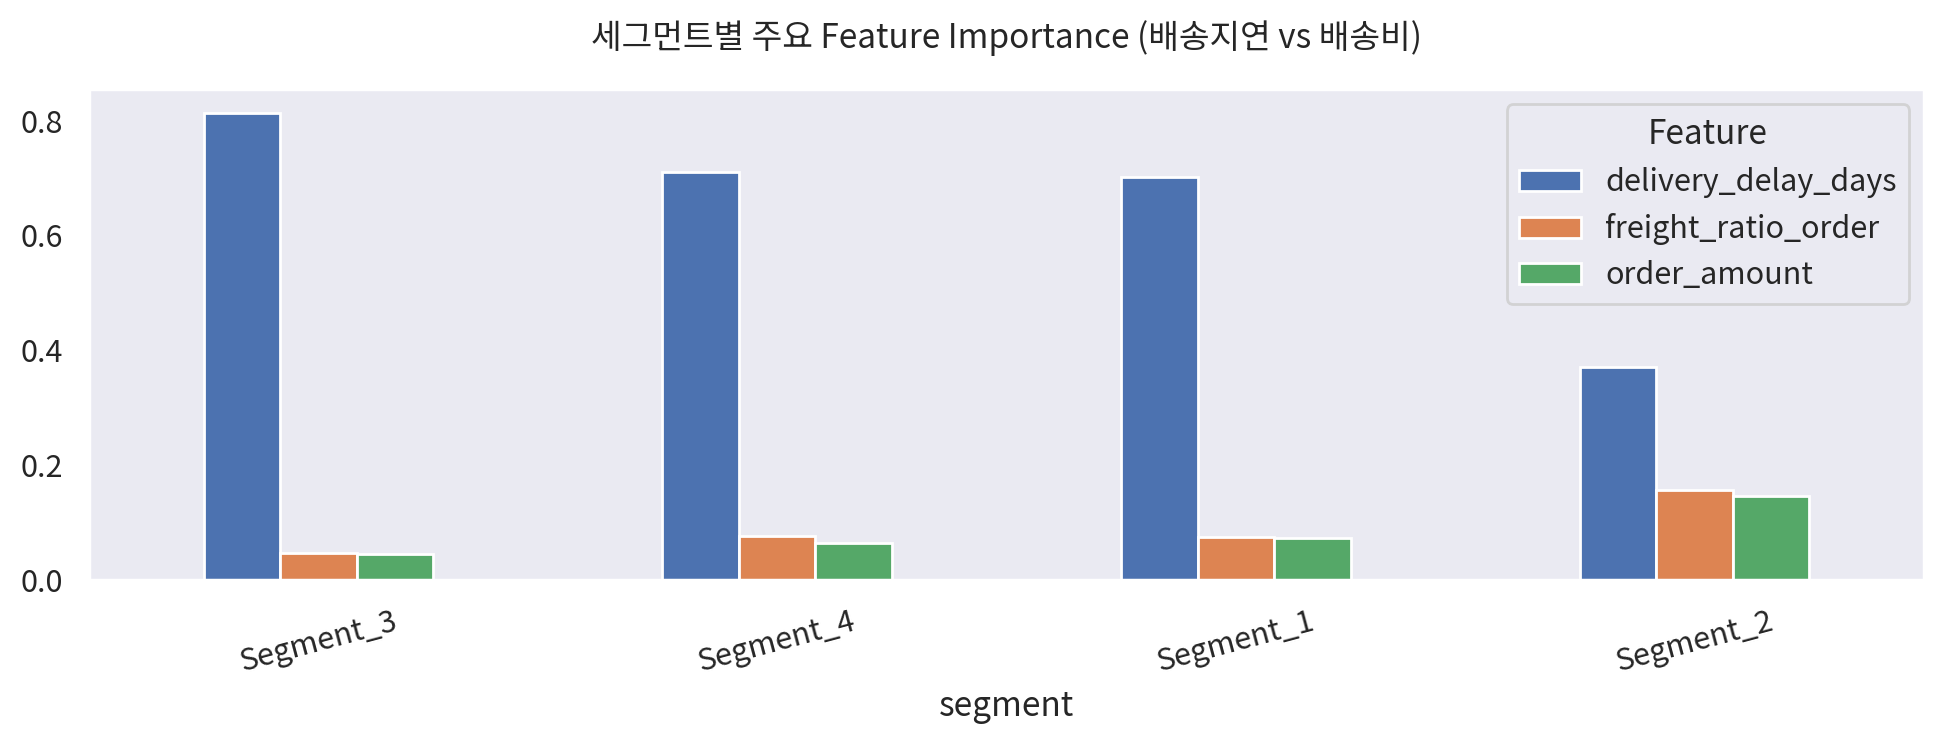

In [19]:
# 세그먼트별로 모델 학습 후 Feature Importance 비교 (배송 지연/배송비 민감도)
segment_importance = []
for seg in order_level['segment'].unique():
    mask = order_level['segment'] == seg
    X_s = order_level.loc[mask, model_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_s = order_level.loc[mask, 'satisfied']
    if y_s.nunique() < 2 or len(y_s) < 50:
        continue
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.25, random_state=42, stratify=y_s)
    rf_seg = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
    rf_seg.fit(X_tr, y_tr)
    imp = pd.Series(rf_seg.feature_importances_, index=model_cols).to_dict()
    imp['segment'] = seg
    segment_importance.append(imp)

imp_df = pd.DataFrame(segment_importance)
print('세그먼트별 Feature Importance (배송 지연 / 배송비 비중 강조):')
display(imp_df)

# 시각화: delivery_delay_days, freight_ratio_order 세그먼트별 중요도
plot_imp = imp_df.set_index('segment')[['delivery_delay_days', 'freight_ratio_order', 'order_amount']]
plot_imp.plot(kind='bar', figsize=(10, 4), title='세그먼트별 주요 Feature Importance (배송지연 vs 배송비)')
plt.xticks(rotation=15)
plt.legend(title='Feature')
plt.tight_layout()
plt.show()

In [20]:
# Plotly로 세그먼트별 Importance 비교
imp_long = imp_df.melt(id_vars='segment', var_name='feature', value_name='importance')
fig = px.bar(imp_long, x='segment', y='importance', color='feature', barmode='group',
             title='세그먼트별 Feature Importance (배송 지연·배송비 민감도 비교)')
fig.update_layout(xaxis_tickangle=-30)
fig.show()

---
## Step 4: 세그먼트별 월별 매출 시계열 및 6개월 예측

In [21]:
# 주문-고객-세그먼트 + 구매월
oi['order_month'] = oi['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly = oi.merge(customer_features[['customer_unique_id', 'segment']], on='customer_unique_id', how='left')
monthly_revenue = monthly.groupby(['order_month', 'segment'])['price'].sum().reset_index(name='revenue')

# Prophet 사용 가능 시 사용, 불가 시 Exponential Smoothing
try:
    from prophet import Prophet
    USE_PROPHET = True
except ImportError:
    USE_PROPHET = False
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

print('Prophet 사용:', USE_PROPHET)

Prophet 사용: True


In [22]:
def forecast_segment(df_seg, n_forecast=6, use_prophet=USE_PROPHET):
    """ 세그먼트별 월매출 시계열 -> 향후 n_forecast 개월 예측 """
    df_seg = df_seg.sort_values('order_month')
    if use_prophet:
        pdf = df_seg.rename(columns={'order_month': 'ds', 'revenue': 'y'})
        pdf['ds'] = pd.to_datetime(pdf['ds'] + '-01')
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
        m.fit(pdf)
        future = m.make_future_dataframe(periods=n_forecast, freq='MS')
        pred = m.predict(future)
        pred = pred[['ds', 'yhat']].rename(columns={'ds': 'order_month', 'yhat': 'revenue_pred'})
        pred['order_month'] = pred['order_month'].dt.to_period('M').astype(str)
        return pred
    else:
        # Exponential Smoothing (월별 합계). 데이터 길이에 따라 seasonal 조정
        df_seg = df_seg.drop_duplicates(subset=['order_month'])
        ts = df_seg.set_index('order_month')['revenue'].sort_index()
        if len(ts) < 3:
            return pd.DataFrame()
        sp = min(12, len(ts) // 2) if len(ts) >= 6 else 0
        try:
            if sp >= 2:
                model = ExponentialSmoothing(ts.values, seasonal_periods=sp, trend='add', seasonal='add')
            else:
                model = ExponentialSmoothing(ts.values, trend='add')
            fit = model.fit()
            fcast = fit.forecast(steps=n_forecast)
            last_dt = pd.to_datetime(ts.index[-1] + '-01')
            fcast_dates = [(last_dt + pd.DateOffset(months=i+1)).strftime('%Y-%m') for i in range(n_forecast)]
            return pd.DataFrame({'order_month': fcast_dates, 'revenue_pred': fcast})
        except Exception:
            last_val = ts.iloc[-1]
            trend = (ts.iloc[-1] - ts.iloc[0]) / len(ts) if len(ts) > 1 else 0
            return pd.DataFrame({'order_month': [f'F{i+1}' for i in range(n_forecast)], 'revenue_pred': [last_val + trend * (i+1) for i in range(n_forecast)]})

# 세그먼트별 예측 수행
forecasts = []
for seg in monthly_revenue['segment'].unique():
    df_seg = monthly_revenue[monthly_revenue['segment'] == seg][['order_month', 'revenue']]
    try:
        pred = forecast_segment(df_seg, n_forecast=6, use_prophet=USE_PROPHET)
        pred['segment'] = seg
        forecasts.append(pred)
    except Exception as e:
        print(f'Segment {seg} 예측 실패:', e)

forecast_df = pd.concat(forecasts, ignore_index=True) if forecasts else pd.DataFrame()
print('예측 결과 샘플:')
display(forecast_df.head(10))

18:23:31 - cmdstanpy - INFO - Chain [1] start processing
18:23:40 - cmdstanpy - INFO - Chain [1] done processing
18:23:40 - cmdstanpy - INFO - Chain [1] start processing
18:23:48 - cmdstanpy - INFO - Chain [1] done processing
18:23:48 - cmdstanpy - INFO - Chain [1] start processing
18:23:56 - cmdstanpy - INFO - Chain [1] done processing
18:23:56 - cmdstanpy - INFO - Chain [1] start processing
18:24:04 - cmdstanpy - INFO - Chain [1] done processing


예측 결과 샘플:


,order_month,revenue_pred,segment
0,2016-09,134.974,Segment_4
1,2016-10,8648.736,Segment_4
2,2016-12,10.892,Segment_4
3,2017-01,19493.566,Segment_4
4,2017-02,33774.402,Segment_4
5,2017-03,52995.591,Segment_4
6,2017-04,47257.793,Segment_4
7,2017-05,76854.400,Segment_4
8,2017-06,64305.212,Segment_4
9,2017-07,54569.156,Segment_4


In [23]:
# 시각화: 세그먼트별 과거 매출 + 향후 6개월 예측
monthly_revenue['type'] = 'actual'
if not forecast_df.empty:
    forecast_plot = forecast_df.rename(columns={'revenue_pred': 'revenue'})[['order_month', 'segment', 'revenue']]
    forecast_plot['type'] = 'forecast'
    plot_df = pd.concat([
        monthly_revenue[['order_month', 'segment', 'revenue', 'type']],
        forecast_plot
    ], ignore_index=True)
else:
    plot_df = monthly_revenue[['order_month', 'segment', 'revenue', 'type']].copy()

fig = px.line(plot_df, x='order_month', y='revenue', color='segment', line_dash='type',
              title='세그먼트별 월매출 추이 및 향후 6개월 예측')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

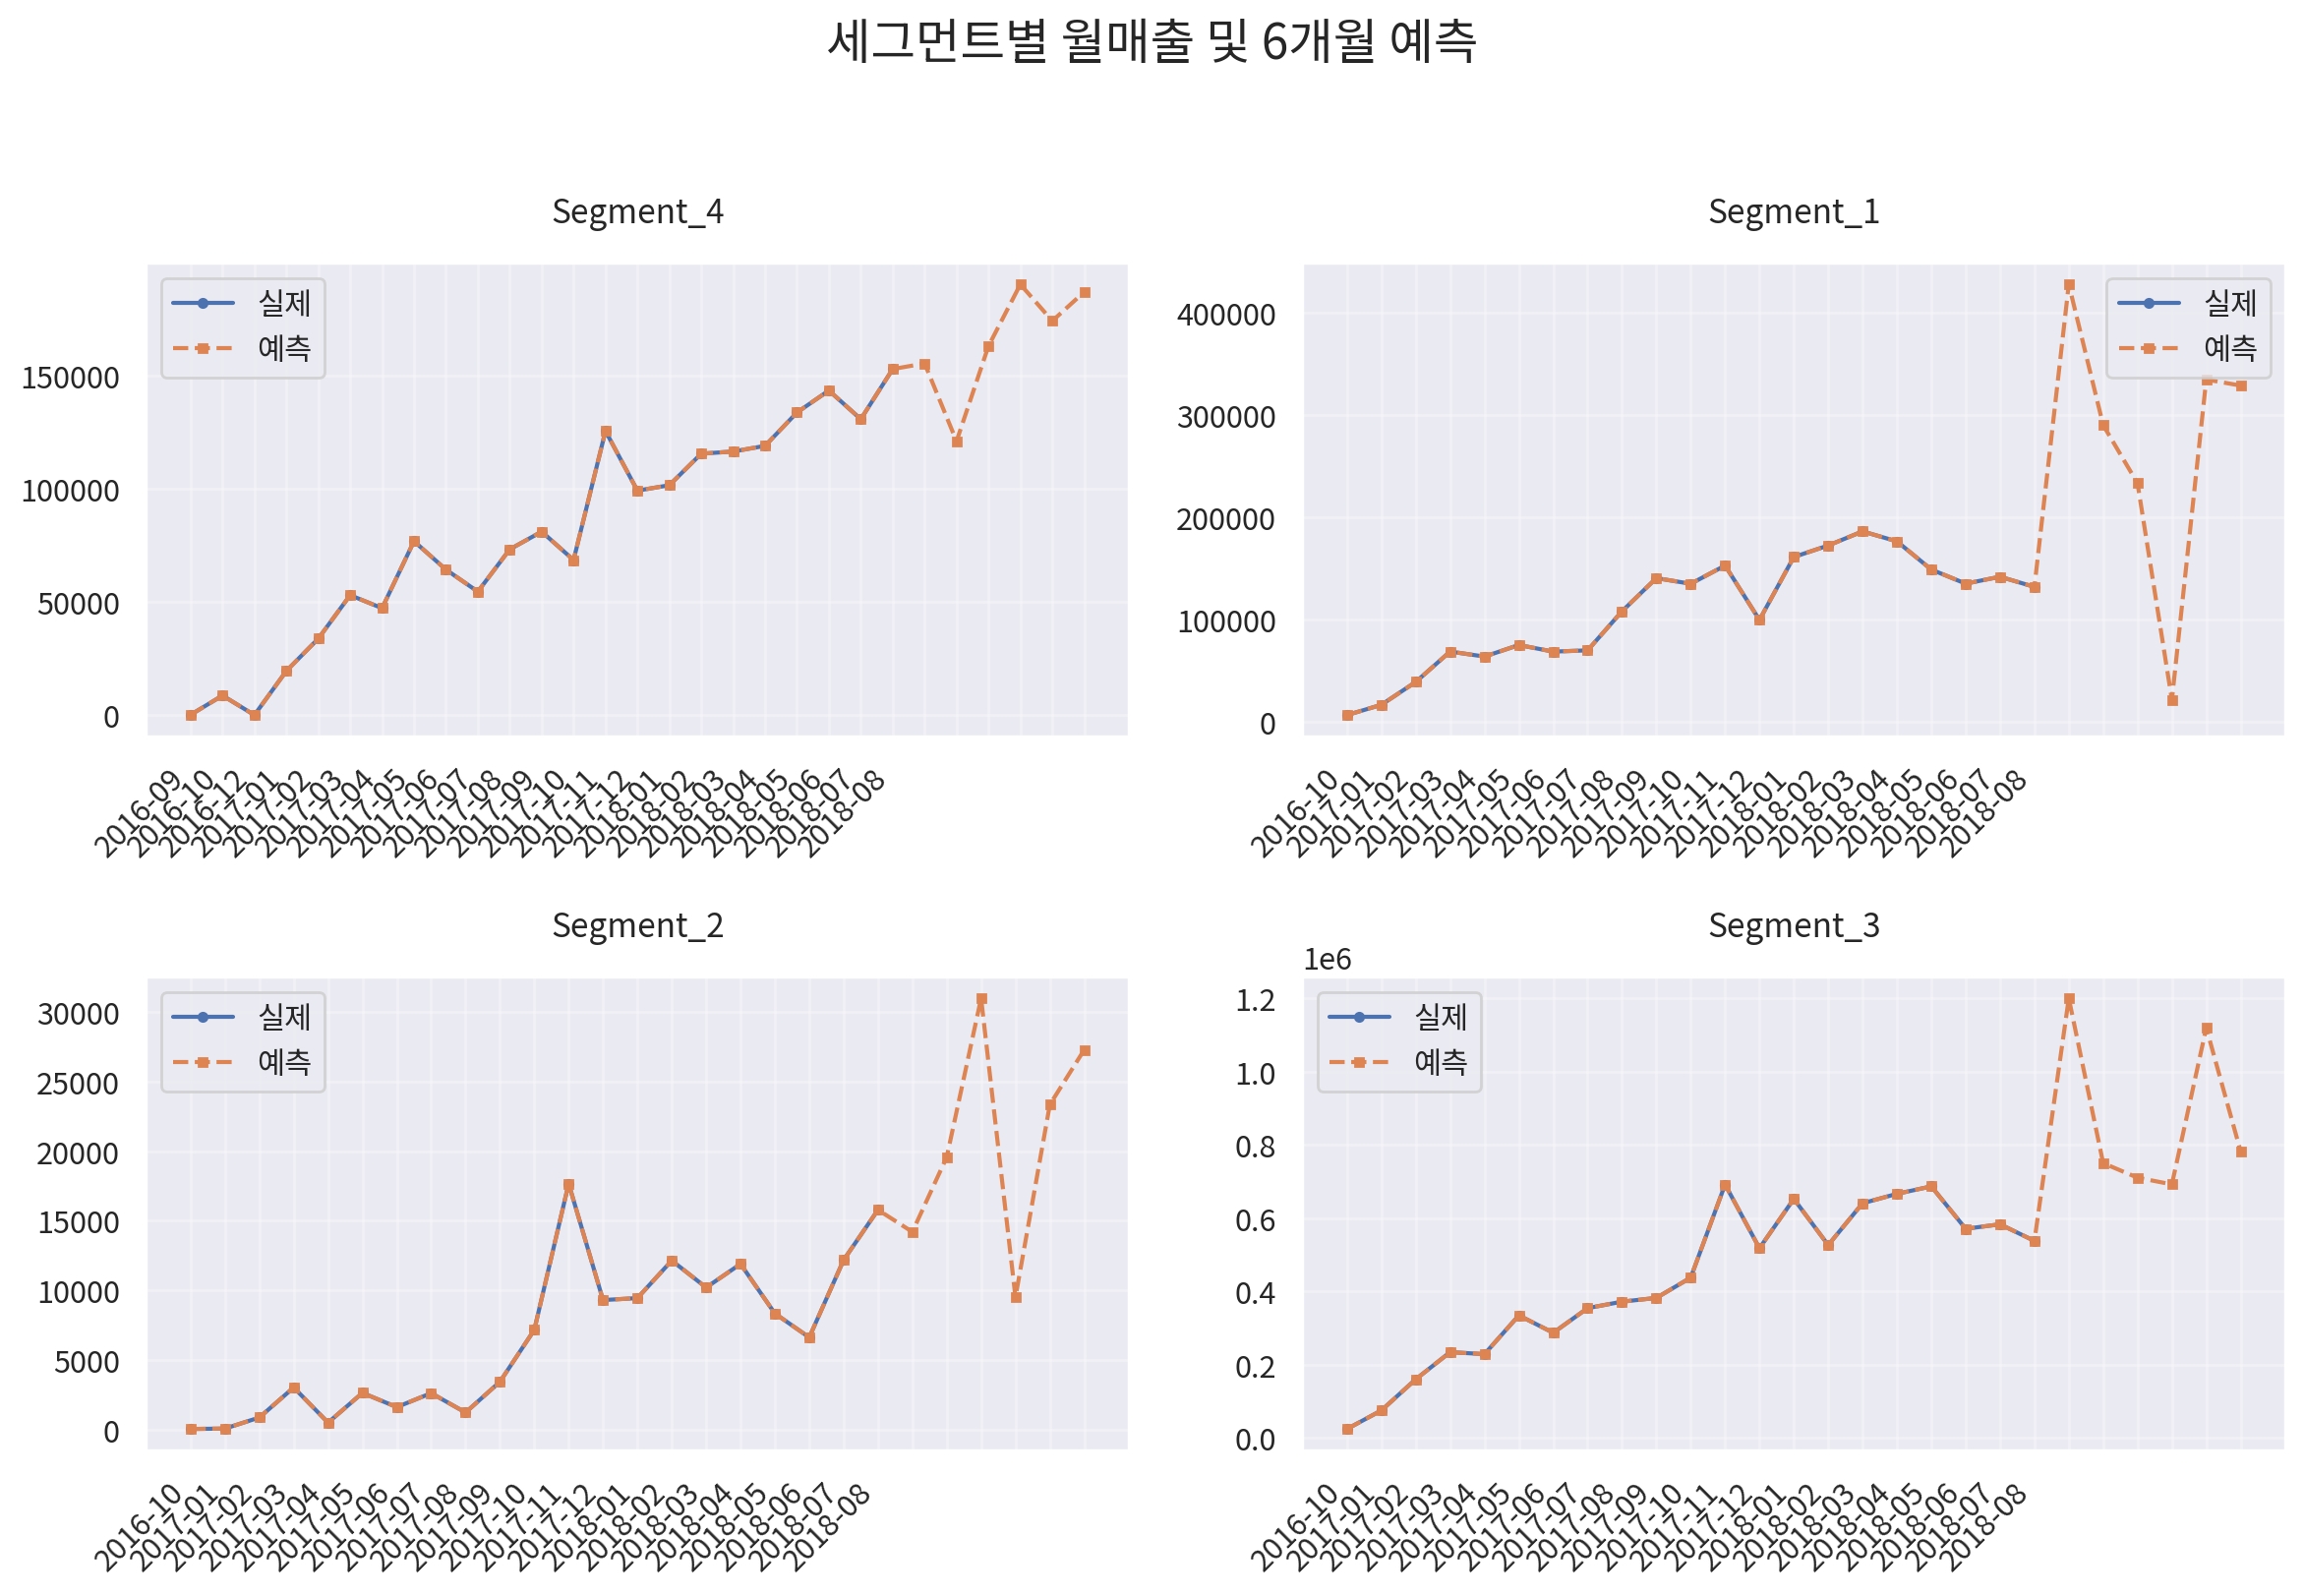

In [24]:
# Matplotlib 대안: 세그먼트별 서브플롯
segments = plot_df['segment'].unique()
n_seg = len(segments)
n_rows = (n_seg + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * max(1, n_rows)))
axes = np.atleast_1d(axes).flatten()
for i, seg in enumerate(segments):
    sub = plot_df[plot_df['segment'] == seg]
    actual = sub[sub['type'] == 'actual']
    forecast = sub[sub['type'] == 'forecast'] if 'forecast' in sub['type'].values else None
    axes[i].plot(actual['order_month'], actual['revenue'], label='실제', marker='o', markersize=3)
    if forecast is not None and len(forecast):
        axes[i].plot(forecast['order_month'], forecast['revenue'], label='예측', linestyle='--', marker='s', markersize=3)
    axes[i].set_title(seg)
    axes[i].set_xticklabels(actual['order_month'].unique(), rotation=45, ha='right')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('세그먼트별 월매출 및 6개월 예측', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 마켓컬리 MD/마케팅팀 제안용 핵심 비즈니스 인사이트 요약

In [25]:
insight_1 = """
1) 카테고리 그룹 (ABCD)
   - A(신선/필수 식품), B(뷰티/패션), C(라이프스타일), D(고가 가전)로 재분류하여 수익성·확장 전략의 기준 축으로 활용할 수 있습니다.
   - 그룹별 매출 비중을 지속 모니터링하고, 컬리 강점인 A를 확대하면서 B·C 확장 시 D와의 크로스셀 기회를 검토하세요.
"""
insight_2 = """
2) 세그먼트 페르소나
   - 식품 중심/가전 고가/라이트 유저/뷰티·패션/라이프스타일 다구매 등으로 구분된 세그먼트별로 맞춤 프로모션과 배송 정책을 설계할 수 있습니다.
   - 고빈도·고객단가 세그먼트에 LTV 확대 프로그램, 라이트 유저에는 첫 구매 재유도 캠페인을 권장합니다.
"""
insight_3 = """
3) 만족도 예측 및 배송 민감도
   - review_score(4–5점 vs 1–3점) 분류 모델로 세그먼트별 Feature Importance를 비교한 결과, 특정 세그먼트는 '배송 지연'에, 다른 세그먼트는 '배송비 비중'에 더 민감할 수 있습니다.
   - 배송 지연에 민감한 세그먼트: 예상 도착일 관리·프리미엄 배송 옵션 강화.
   - 배송비에 민감한 세그먼트: 무료배송 기준 완화, 번들 구매 인센티브 등으로 만족도 개선을 제안합니다.
"""
insight_4 = """
4) 세그먼트별 매출 성장 예측
   - 월별 매출 시계열과 Prophet/Exponential Smoothing 기반 6개월 예측으로 세그먼트별 성장 추이를 파악할 수 있습니다.
   - 성장이 둔화되는 세그먼트에는 마케팅 집행 강화, 성장이 빠른 세그먼트에는 재고·배송 역량 확대를 권장합니다.
"""
print('=== 마켓컬리 MD/마케팅팀 제안용 핵심 인사이트 ===')
print(insight_1, insight_2, insight_3, insight_4)

=== 마켓컬리 MD/마케팅팀 제안용 핵심 인사이트 ===

1) 카테고리 그룹 (ABCD)
   - A(신선/필수 식품), B(뷰티/패션), C(라이프스타일), D(고가 가전)로 재분류하여 수익성·확장 전략의 기준 축으로 활용할 수 있습니다.
   - 그룹별 매출 비중을 지속 모니터링하고, 컬리 강점인 A를 확대하면서 B·C 확장 시 D와의 크로스셀 기회를 검토하세요.
 
2) 세그먼트 페르소나
   - 식품 중심/가전 고가/라이트 유저/뷰티·패션/라이프스타일 다구매 등으로 구분된 세그먼트별로 맞춤 프로모션과 배송 정책을 설계할 수 있습니다.
   - 고빈도·고객단가 세그먼트에 LTV 확대 프로그램, 라이트 유저에는 첫 구매 재유도 캠페인을 권장합니다.
 
3) 만족도 예측 및 배송 민감도
   - review_score(4–5점 vs 1–3점) 분류 모델로 세그먼트별 Feature Importance를 비교한 결과, 특정 세그먼트는 '배송 지연'에, 다른 세그먼트는 '배송비 비중'에 더 민감할 수 있습니다.
   - 배송 지연에 민감한 세그먼트: 예상 도착일 관리·프리미엄 배송 옵션 강화.
   - 배송비에 민감한 세그먼트: 무료배송 기준 완화, 번들 구매 인센티브 등으로 만족도 개선을 제안합니다.
 
4) 세그먼트별 매출 성장 예측
   - 월별 매출 시계열과 Prophet/Exponential Smoothing 기반 6개월 예측으로 세그먼트별 성장 추이를 파악할 수 있습니다.
   - 성장이 둔화되는 세그먼트에는 마케팅 집행 강화, 성장이 빠른 세그먼트에는 재고·배송 역량 확대를 권장합니다.

